<>:134: SyntaxWarning: invalid escape sequence '\D'
<>:137: SyntaxWarning: invalid escape sequence '\m'
<>:134: SyntaxWarning: invalid escape sequence '\D'
<>:137: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2252/3058087750.py:134: SyntaxWarning: invalid escape sequence '\D'
  ax1.set_title(f'Right-to-Left Topological Annealing (500 Points): Cooling $\Delta\mu = -{DELTA_MU_ABS}$', fontsize=16)
/tmp/ipykernel_2252/3058087750.py:137: SyntaxWarning: invalid escape sequence '\m'
  text_str = f"Dynamical Cooling Model:\n$\mu_n = U_C + k / \ln^2(n+10)$\nSteps ($n$) = $10^7$\nCooling Width = {DELTA_MU_ABS}"


🚀 启动【从右向左冷却】500点微扰扫描 | 冷却降幅: Δμ = -0.02

理论深渊 U_C        | 起始 μ (极热)      | 结束 μ (冷却)       | R²       | 平均误差
----------------------------------------------------------------------------
1.199547        | 1.220000       | 1.200000        | 0.9831   | 3.2889
1.278104        | 1.298557       | 1.278557        | 0.9737   | 4.6069
1.358265        | 1.378717       | 1.358717        | 0.9763   | 3.9440
1.438425        | 1.458878       | 1.438878        | 0.9889   | 5.2765
1.518585        | 1.539038       | 1.519038        | 0.9920   | 4.2803
1.598746        | 1.619198       | 1.599198        | 0.9889   | 4.9388
1.678906        | 1.699359       | 1.679359        | 0.9927   | 3.9364
1.759066        | 1.779519       | 1.759519        | 0.9567   | 3.9682
1.839227        | 1.859679       | 1.839679        | 0.9906   | 4.5177
1.919387        | 1.939840       | 1.919840        | 0.9932   | 3.9447
1.999547        | 2.020000       | 2.000000        | 0.0000   | 20.0000
-------------------------------

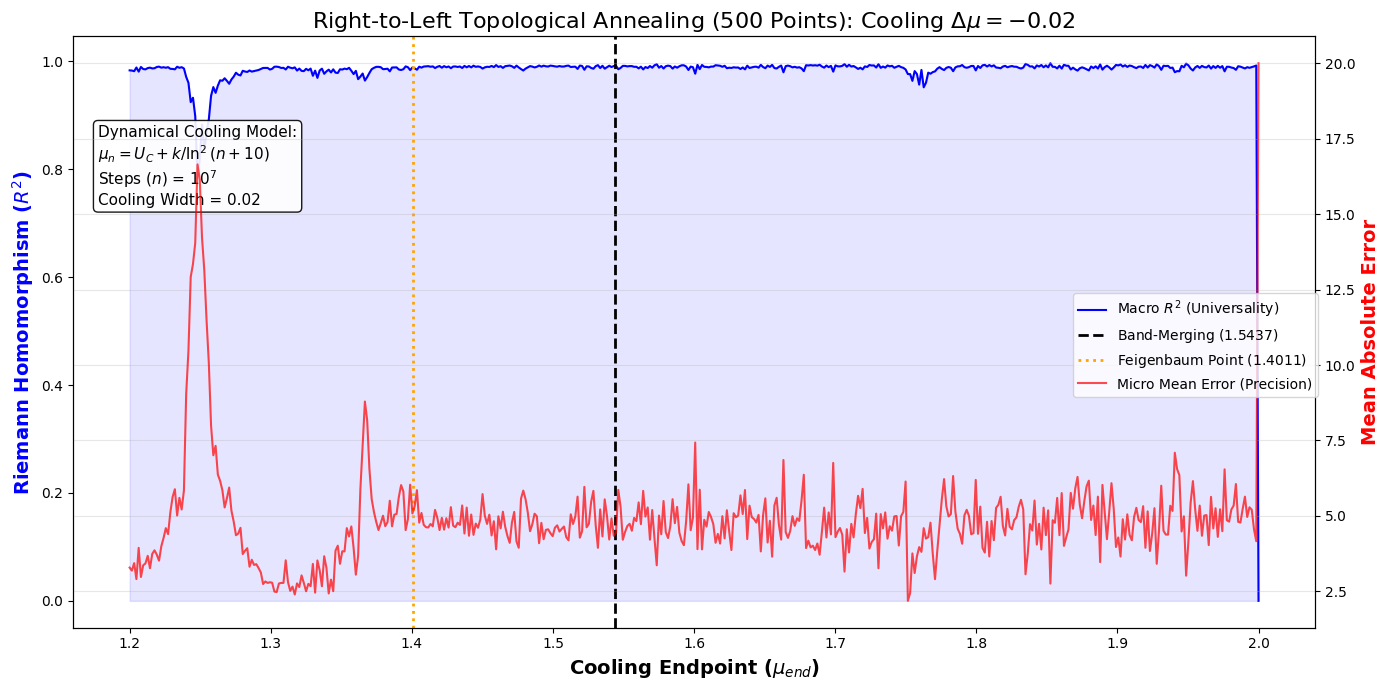

In [1]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigs
from scipy.stats import linregress
import mpmath
import matplotlib.pyplot as plt
import time
from numba import njit

# 真实的黎曼零点
mpmath.mp.dps = 15
N_ZEROS = 100
TRUE_ZEROS = np.array([float(mpmath.zetazero(i).imag) for i in range(1, N_ZEROS + 1)])

@njit
def run_universe_annealing(steps, n_bins, u_c, k_opt, c_offset):
    transitions = np.zeros((n_bins, n_bins), dtype=np.uint32)
    x = 0.5
    last_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
    
    for i in range(1, steps + 1):
        # 🎯 核心修改：使用加号，从右侧（高能混沌区）向下退火冷却！
        mu_raw = u_c + k_opt / (np.log(i + c_offset)**2)
        
        # 物理保险丝：防止参数超过 2.0 导致宇宙彻底崩溃
        if mu_raw > 2.0: 
            mu = 2.0
        elif mu_raw < 0.1:
            mu = 0.1
        else:
            mu = mu_raw
            
        x = 1.0 - mu * x * x
        if x > 1.0: x = 0.999
        elif x < -1.0: x = -0.999
            
        current_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
        transitions[last_bin, current_bin] += 1
        last_bin = current_bin
        
    return transitions

# ================= 🔬 微扰卡尺参数设置区 =================
# 1. 横轴显示真正的结束点 (mu_end_points)
# 从 1.40 到 2.00，覆盖费根鲍姆点到最大混沌区
test_points_end = np.linspace(1.20, 2.00, 500)

# 2. 演化物理步数与对数平滑常数
TOTAL_STEPS = 10**7
C_OFFSET = 10.0   

# 3. 极其微小的冷却漂移宽度 (游标卡尺宽度)
# 我们希望在 10^7 步里，mu 从右向左降温 0.02
DELTA_MU_ABS = 0.02  

results_R2 = []
results_mean_err = []

print(f"🚀 启动【从右向左冷却】500点微扰扫描 | 冷却降幅: Δμ = -{DELTA_MU_ABS}\n")
print(f"{'理论深渊 U_C':<15} | {'起始 μ (极热)':<14} | {'结束 μ (冷却)':<15} | {'R²':<8} | {'平均误差'}")
print("-" * 76)

start_total_t = time.time()

for idx, mu_end in enumerate(test_points_end):
    # 🎯 逆向推导逻辑 (针对加号公式: mu = U_c + K*t)
    t_start_val = 1.0 / (np.log(1 + C_OFFSET)**2)
    t_end_val   = 1.0 / (np.log(TOTAL_STEPS + C_OFFSET)**2)
    
    # 因为 mu_start > mu_end，所以 DELTA_MU_ABS = K * (t_start_val - t_end_val)
    k_opt = DELTA_MU_ABS / (t_start_val - t_end_val)
    
    # mu_end = U_C + K * t_end_val  =>  U_C = mu_end - K * t_end_val
    u_c = mu_end - k_opt * t_end_val
    
    # 算出起点验证: 应该等于 mu_end + 0.02
    mu_start = u_c + k_opt * t_start_val
    
    # 注入冷却演化
    trans = run_universe_annealing(TOTAL_STEPS, 5000, u_c, k_opt, C_OFFSET)
    
    P_sparse = sp.csr_matrix(trans, dtype=np.float64)
    row_sums = np.array(P_sparse.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1.0 
    P_sparse.data /= row_sums[P_sparse.indices]
    
    try:
        eigenvalues, _ = eigs(P_sparse, k=N_ZEROS + 20, which='LM', tol=1e-4)
        phases = np.sort(np.angle(eigenvalues[np.abs(eigenvalues.imag) > 1e-4]))
        unwrapped = np.unwrap(phases)
        
        min_len = min(len(unwrapped), N_ZEROS)
        
        if min_len > 10:
            unwrapped_trunc = unwrapped[:min_len]
            true_zeros_trunc = TRUE_ZEROS[:min_len]
            
            slope, intercept, r_val, _, _ = linregress(unwrapped_trunc, true_zeros_trunc)
            pred = slope * unwrapped_trunc + intercept
            err = np.mean(np.abs(pred - true_zeros_trunc))
            r2 = r_val**2
        else:
            err = 20.0 
            r2 = 0.0
            
    except Exception:
        err = 20.0
        r2 = 0.0
        
    results_R2.append(r2)
    results_mean_err.append(err)
    
    # 实时打印：每 50 个点汇报一次
    if (idx + 1) % 50 == 0 or idx == 0:
        print(f"{u_c:<15.6f} | {mu_start:<14.6f} | {mu_end:<15.6f} | {r2:<8.4f} | {err:.4f}")

print("-" * 76)
print(f"✅ 冷却扫描完成！总耗时: {(time.time()-start_total_t)/60:.2f} 分钟")

# ================= 高清绘图环节 =================
fig, ax1 = plt.subplots(figsize=(14, 7))

ax1_twin = ax1.twinx()
ax1.plot(test_points_end, results_R2, 'b-', lw=1.5, label='Macro $R^2$ (Universality)')
ax1.fill_between(test_points_end, results_R2, color='blue', alpha=0.1)
ax1_twin.plot(test_points_end, results_mean_err, 'r-', lw=1.5, alpha=0.7, label='Micro Mean Error (Precision)')

ax1.axvline(1.543689, color='k', linestyle='--', lw=2, label='Band-Merging ($1.5437$)')
ax1.axvline(1.401155, color='orange', linestyle=':', lw=2, label='Feigenbaum Point ($1.4011$)')

ax1.set_xlabel(r'Cooling Endpoint ($\mu_{end}$)', fontsize=14, fontweight='bold')
ax1.set_ylabel(r'Riemann Homomorphism ($R^2$)', color='b', fontsize=14, fontweight='bold')
ax1_twin.set_ylabel('Mean Absolute Error', color='r', fontsize=14, fontweight='bold')
ax1.set_title(f'Right-to-Left Topological Annealing (500 Points): Cooling $\Delta\mu = -{DELTA_MU_ABS}$', fontsize=16)

# 标记文本框解释冷却动态
text_str = f"Dynamical Cooling Model:\n$\mu_n = U_C + k / \ln^2(n+10)$\nSteps ($n$) = $10^7$\nCooling Width = {DELTA_MU_ABS}"
ax1.text(0.02, 0.85, text_str, transform=ax1.transAxes, fontsize=11,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

fig.legend(loc='center right', bbox_to_anchor=(0.95, 0.5), ncol=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()